In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/synthetic/kavach_synthetic.csv')

print("Dataset loaded:", df.shape)
print(f"\nNormal events:  {(df['is_anomaly']==0).sum()}")
print(f"Anomaly events: {(df['is_anomaly']==1).sum()}")


Dataset loaded: (10000, 16)

Normal events:  9514
Anomaly events: 486


In [4]:
# Features the anomaly detector watches
features = ['speed_kmh', 'rfid_read_success', 
            'radio_packet_loss_pct', 'weather_index',
            'freight_load_tonnes', 'deceleration_rate']

# Separate normal and anomaly data
normal_data  = df[df['is_anomaly'] == 0][features]
anomaly_data = df[df['is_anomaly'] == 1][features]

print("Normal data shape:",  normal_data.shape)
print("Anomaly data shape:", anomaly_data.shape)

# Scale all values to 0-1 range (important for LSTM)
scaler = MinMaxScaler()
normal_scaled  = scaler.fit_transform(normal_data)
anomaly_scaled = scaler.transform(anomaly_data)

print("\nScaling done — all values now between 0 and 1")
print("Sample normal row:", normal_scaled[0].round(3))

Normal data shape: (9514, 6)
Anomaly data shape: (486, 6)

Scaling done — all values now between 0 and 1
Sample normal row: [0.554 1.    0.614 0.187 0.929 0.645]


In [5]:
# LSTM needs data in sequences (windows of time)
# We'll use 30 events at a time as one sequence
SEQUENCE_LENGTH = 30

def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

# Create sequences from normal data only for training
normal_sequences = create_sequences(normal_scaled, SEQUENCE_LENGTH)

# Split normal sequences: 80% train, 20% validation
split = int(len(normal_sequences) * 0.8)
X_train = normal_sequences[:split]
X_val   = normal_sequences[split:]

print(f"Sequence length:      {SEQUENCE_LENGTH} events per sequence")
print(f"Total sequences:      {len(normal_sequences)}")
print(f"Training sequences:   {len(X_train)}")
print(f"Validation sequences: {len(X_val)}")
print(f"\nShape of X_train: {X_train.shape}")
print("(samples, timesteps, features)")

Sequence length:      30 events per sequence
Total sequences:      9484
Training sequences:   7587
Validation sequences: 1897

Shape of X_train: (7587, 30, 6)
(samples, timesteps, features)


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed

# Set seed for reproducibility
tf.random.set_seed(42)

# Build the Autoencoder
inputs = Input(shape=(SEQUENCE_LENGTH, 6))

# Encoder - compresses the sequence
encoded = LSTM(64, activation='relu', return_sequences=False)(inputs)

# Bottleneck - smallest compressed representation
bottleneck = RepeatVector(SEQUENCE_LENGTH)(encoded)

# Decoder - tries to reconstruct the original sequence
decoded = LSTM(64, activation='relu', return_sequences=True)(bottleneck)
outputs = TimeDistributed(Dense(6))(decoded)

# Complete model
model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mae')

# Show model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape        ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 30, 6)       │          0 │
├───────────────────────────┼─────────────────────┼────────────┤
│ lstm (LSTM)               │ (None, 64)          │     18,176 │
├───────────────────────────┼─────────────────────┼────────────┤
│ repeat_vector             │ (None, 30, 64)      │          0 │
│ (RepeatVector)            │                     │            │
├───────────────────────────┼─────────────────────┼────────────┤
│ lstm_1 (LSTM)             │ (None, 30, 64)      │     33,024 │
├───────────────────────────┼─────────────────────┼────────────┤
│ time_distributed          │ (None, 30, 6)       │        390 │
│ (TimeDistributed)         │                     │            │
└───────────────────────────┴─────────────────────┴────────────┘

 Total params: 51,590 (201.52 KB)

 Trainable params: 51,590 (201.52 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the autoencoder on normal data only
print("Training the LSTM Autoencoder...")
print("This will take 2-3 minutes...\n")

history = model.fit(
    X_train, X_train,        # input and output are the same!
    epochs=20,               # 20 passes through the data
    batch_size=32,
    validation_data=(X_val, X_val),
    shuffle=True,
    verbose=1                # shows progress
)

print("\nTraining complete!")

Training the LSTM Autoencoder...
This will take 2-3 minutes...

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - loss: 0.2147 - val_loss: 0.1879
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1866 - val_loss: 0.1873
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1854 - val_loss: 0.1881
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1843 - val_loss: 0.1854
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1838 - val_loss: 0.1850
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1836 - val_loss: 0.1847
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1833 - val_loss: 0.1843
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1831 - val_loss: 0.1844
Epoch 9/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1829 - val_loss: 0.1841
Epoch 10/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1828 - val_loss: 0.1837
Epoch 11/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.

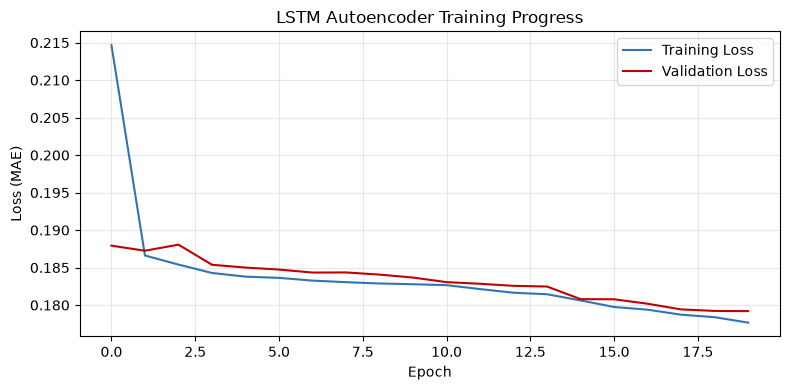

Starting loss: 0.2147
Final loss:    0.1777
Improvement:   17.2%


In [8]:
# Plot training vs validation loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss', color='#2E75B6')
plt.plot(history.history['val_loss'], label='Validation Loss', color='#C00000')
plt.title('LSTM Autoencoder Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Starting loss: {history.history['loss'][0]:.4f}")
print(f"Final loss:    {history.history['loss'][-1]:.4f}")
print(f"Improvement:   {((history.history['loss'][0] - history.history['loss'][-1]) / history.history['loss'][0] * 100):.1f}%")


238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
Reconstruction Error Analysis:
  Mean error (normal): 0.1777
  Max error (normal):  0.2135
  Threshold (95th):    0.1970

Any sequence with error above 0.1970 will be flagged as ANOMALY


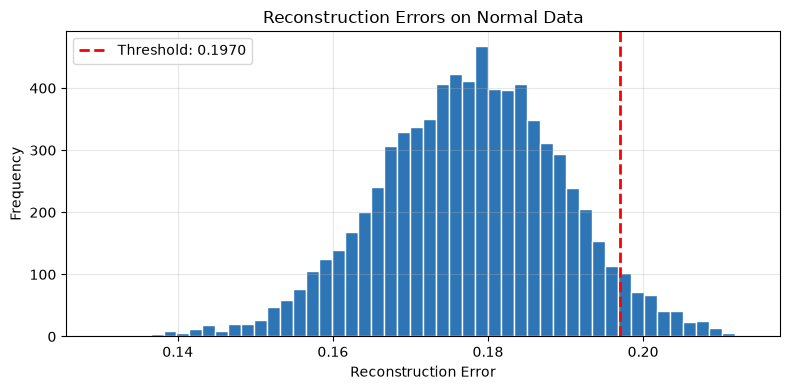

In [9]:
# Get reconstruction errors on normal training data
train_predictions = model.predict(X_train)
train_errors = np.mean(np.abs(train_predictions - X_train), axis=(1,2))

# Set threshold at 95th percentile
# Anything above this = anomaly
threshold = np.percentile(train_errors, 95)

print("Reconstruction Error Analysis:")
print(f"  Mean error (normal): {train_errors.mean():.4f}")
print(f"  Max error (normal):  {train_errors.max():.4f}")
print(f"  Threshold (95th):    {threshold:.4f}")
print(f"\nAny sequence with error above {threshold:.4f} will be flagged as ANOMALY")

# Plot error distribution
plt.figure(figsize=(8, 4))
plt.hist(train_errors, bins=50, color='#2E75B6', edgecolor='white')
plt.axvline(x=threshold, color='red', linestyle='--', 
            linewidth=2, label=f'Threshold: {threshold:.4f}')
plt.title('Reconstruction Errors on Normal Data')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Anomaly sequences created: 456
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Normal data errors:  avg = 0.1777
Anomaly data errors: avg = 73.6459

Anomaly errors are 414.5x higher than normal!


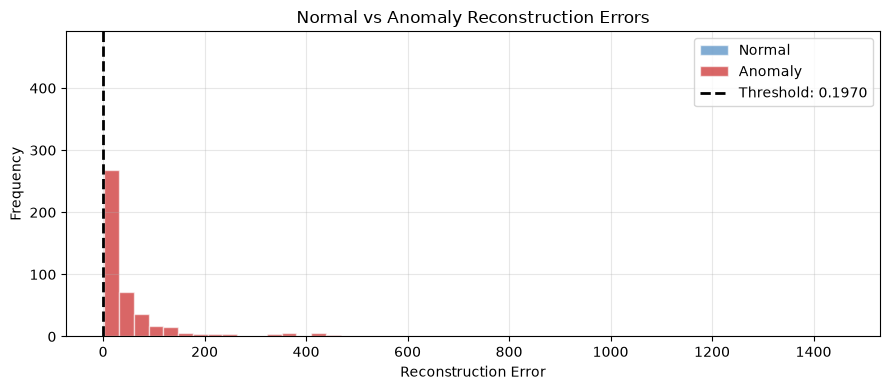

In [10]:
# Create sequences from anomaly data
anomaly_sequences = create_sequences(anomaly_scaled, SEQUENCE_LENGTH)
print(f"Anomaly sequences created: {len(anomaly_sequences)}")

# Get reconstruction errors for anomaly sequences
anomaly_predictions = model.predict(anomaly_sequences)
anomaly_errors = np.mean(np.abs(anomaly_predictions - anomaly_sequences), axis=(1,2))

print(f"\nNormal data errors:  avg = {train_errors.mean():.4f}")
print(f"Anomaly data errors: avg = {anomaly_errors.mean():.4f}")
print(f"\nAnomaly errors are {anomaly_errors.mean()/train_errors.mean():.1f}x higher than normal!")

# Plot both distributions together
plt.figure(figsize=(9, 4))
plt.hist(train_errors, bins=50, alpha=0.6, 
         color='#2E75B6', label='Normal', edgecolor='white')
plt.hist(anomaly_errors, bins=50, alpha=0.6, 
         color='#C00000', label='Anomaly', edgecolor='white')
plt.axvline(x=threshold, color='black', linestyle='--',
            linewidth=2, label=f'Threshold: {threshold:.4f}')
plt.title('Normal vs Anomaly Reconstruction Errors')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

   ANOMALY DETECTION EVALUATION
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97      7587
     Anomaly       0.55      1.00      0.71       456

    accuracy                           0.95      8043
   macro avg       0.77      0.97      0.84      8043
weighted avg       0.97      0.95      0.96      8043



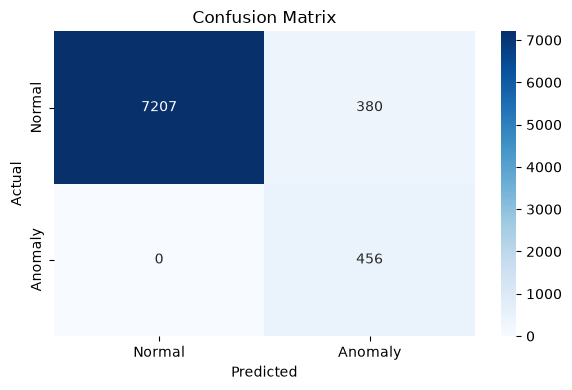

In [11]:
# Classify sequences as normal or anomaly based on threshold
normal_preds   = (train_errors > threshold).astype(int)
anomaly_preds  = (anomaly_errors > threshold).astype(int)

# Combine for full evaluation
all_errors = np.concatenate([train_errors, anomaly_errors])
all_true   = np.concatenate([
    np.zeros(len(train_errors)),   # normal = 0
    np.ones(len(anomaly_errors))   # anomaly = 1
])
all_preds  = (all_errors > threshold).astype(int)

# Print classification report
print("=" * 45)
print("   ANOMALY DETECTION EVALUATION")
print("=" * 45)
print(classification_report(all_true, all_preds, 
      target_names=['Normal', 'Anomaly']))

# Confusion matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [12]:
# Rebuild and retrain with more epochs
tf.random.set_seed(42)

inputs = Input(shape=(SEQUENCE_LENGTH, 6))
encoded = LSTM(128, activation='relu', return_sequences=False)(inputs)
bottleneck = RepeatVector(SEQUENCE_LENGTH)(encoded)
decoded = LSTM(128, activation='relu', return_sequences=True)(bottleneck)
outputs = TimeDistributed(Dense(6))(decoded)

model2 = Model(inputs, outputs)
model2.compile(optimizer='adam', loss='mae')

print("Retraining with bigger model and more epochs...")
print("This will take 5-7 minutes...\n")

history2 = model2.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, X_val),
    shuffle=True,
    verbose=1
)

print("\nRetraining complete!")


Retraining with bigger model and more epochs...
This will take 5-7 minutes...

Epoch 1/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 0.2056 - val_loss: 0.1885
Epoch 2/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.1869 - val_loss: 0.1860
Epoch 3/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.1855 - val_loss: 0.1848
Epoch 4/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.1839 - val_loss: 0.1842
Epoch 5/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.1837 - val_loss: 0.1834
Epoch 6/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.1836 - val_loss: 0.1834
Epoch 7/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 0.1827 - val_loss: 0.1832
Epoch 8/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 0.1818 - val_loss: 0.1823
Epoch 9/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - loss: 0.1811 - val_loss: 0.1813
Epoch 10/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.1807 - val_loss: 0.1817
Epoch 11/50
238/238 ━━━━━━━━━━━━━━━━━━━━

In [13]:
# Get reconstruction errors with new model
train_preds2  = model2.predict(X_train)
train_errors2 = np.mean(np.abs(train_preds2 - X_train), axis=(1,2))

# New threshold
threshold2 = np.percentile(train_errors2, 95)
print(f"New threshold: {threshold2:.4f}")

# Anomaly errors
anomaly_preds2  = model2.predict(anomaly_sequences)
anomaly_errors2 = np.mean(np.abs(anomaly_preds2 - anomaly_sequences), axis=(1,2))

# Full evaluation
all_errors2 = np.concatenate([train_errors2, anomaly_errors2])
all_preds2  = (all_errors2 > threshold2).astype(int)

print("\n" + "=" * 45)
print("   IMPROVED MODEL EVALUATION")
print("=" * 45)
print(classification_report(all_true, all_preds2,
      target_names=['Normal', 'Anomaly']))

238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
New threshold: 0.1791
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step

   IMPROVED MODEL EVALUATION
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97      7587
     Anomaly       0.55      1.00      0.71       456

    accuracy                           0.95      8043
   macro avg       0.77      0.97      0.84      8043
weighted avg       0.97      0.95      0.96      8043



In [14]:
import joblib
import os

os.makedirs('../models/saved', exist_ok=True)

# Save the LSTM model
model2.save('../models/saved/anomaly_model.h5')

# Save the scaler (needed later for predictions)
joblib.dump(scaler, '../models/saved/anomaly_scaler.pkl')

# Save the threshold
joblib.dump(threshold2, '../models/saved/anomaly_threshold.pkl')

print("✅ Anomaly model saved:   models/saved/anomaly_model.h5")
print("✅ Scaler saved:          models/saved/anomaly_scaler.pkl")
print("✅ Threshold saved:       models/saved/anomaly_threshold.pkl")

# Quick verification
from tensorflow.keras.models import load_model
loaded = load_model('../models/saved/anomaly_model.h5')
print("\n✅ Model reloaded successfully!")
print(f"   Threshold in use: {threshold2:.4f}")
print(f"   Any error above this = ANOMALY flagged")

✅ Anomaly model saved:   models/saved/anomaly_model.h5
✅ Scaler saved:          models/saved/anomaly_scaler.pkl
✅ Threshold saved:       models/saved/anomaly_threshold.pkl


ValueError: Could not deserialize 'keras.metrics.mae' because it is not a KerasSaveable subclass

In [15]:
# Resave model in new Keras format
model2.save('../models/saved/anomaly_model.keras')
print("✅ Model resaved in new format!")

✅ Model resaved in new format!
